# ASSISTments 2017 Benchmark Evaluation
Testing the adaptive learning model on ASSISTments 2017 dataset

**Why ASSISTments:**
- Real classroom data from middle school students
- Actual math questions with student responses
- Gold standard in educational data mining research
- ~942K interactions from 686 students on 102 math questions

**Metrics:** Accuracy, F1 Score, AUC

## 1. Setup and Download ASSISTments

In [1]:
!pip install -q datasets transformers accelerate peft bitsandbytes torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.9 MB/s eta 0:00:00


In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from tqdm import tqdm
import json

print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA: True
GPU: NVIDIA A100-SXM4-40GB


### Download ASSISTments Dataset

**Option 1: From Kaggle** (easiest)

In [3]:
# Setup Kaggle credentials
import os
os.environ['KAGGLE_USERNAME'] = 'yahia saqer'
os.environ['KAGGLE_KEY'] = 'KGAT_9502dfc610067da2128caa08ad564633'  # Replace with your key

!pip install -q kaggle

# Download ASSISTments 2009-2010 dataset (most commonly used)
print("Downloading ASSISTments dataset...")
!kaggle datasets download -d nicolaswattiez/skillbuilder-data-2009-2010
!unzip -q skillbuilder-data-2009-2010.zip

print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/nicolaswattiez/skillbuilder-data-2009-2010
License(s): unknown
 79% 497M/629M [00:00<00:00, 1.73GB/s]
100% 629M/629M [00:00<00:00, 1.73GB/s]
Dataset downloaded!


**Option 2: Load from HuggingFace datasets (if available)**

In [4]:
# Alternative: Try loading from datasets library
# from datasets import load_dataset
# assistments = load_dataset("assistments", "2009-2010")

# For now, we'll work with CSV file
print("Loading dataset from CSV...")

Loading dataset from CSV...


## 2. Load and Explore ASSISTments Data

In [5]:
# Load the dataset
df = pd.read_csv('2012-2013-data-with-predictions-4-final.csv', encoding='latin1')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)

Dataset shape: (6123270, 35)

Columns: ['problem_log_id', 'skill', 'problem_id', 'user_id', 'assignment_id', 'assistment_id', 'start_time', 'end_time', 'problem_type', 'original', 'correct', 'bottom_hint', 'hint_count', 'actions', 'attempt_count', 'ms_first_response', 'tutor_mode', 'sequence_id', 'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id', 'teacher_id', 'school_id', 'overlap_time', 'template_id', 'answer_id', 'answer_text', 'first_action', 'problemlogid', 'Average_confidence(FRUSTRATED)', 'Average_confidence(CONFUSED)', 'Average_confidence(CONCENTRATING)', 'Average_confidence(BORED)']

First few rows:
   problem_log_id                                 skill  problem_id  user_id  \
0       137792159                                   NaN      557460    61394   
1       138083797                              Rounding      365981    61394   
2       142332619  Multiplication and Division Integers      426415    61394   
3       145939397                          

In [6]:
# Explore key columns
print("Key Statistics:")
print(f"Unique students: {df['user_id'].nunique()}")
print(f"Unique problems: {df['problem_id'].nunique()}")
print(f"Total interactions: {len(df)}")
print(f"\nCorrectness distribution:")
print(df['correct'].value_counts())
print(f"\nCorrectness rate: {df['correct'].mean():.2%}")

Key Statistics:
Unique students: 46674
Unique problems: 179999
Total interactions: 6123270

Correctness distribution:
correct
1.000    4141564
0.000    1976383
0.500       2395
0.750       1629
0.250       1211
0.600         24
0.975         24
0.850         10
0.650         10
0.950          9
0.875          6
0.625          4
0.375          1
Name: count, dtype: int64

Correctness rate: 67.68%


In [7]:
# Check for problem text
print("\nAvailable fields for questions:")
problem_cols = [col for col in df.columns if 'problem' in col.lower() or 'question' in col.lower()]
print(problem_cols)

# Check for skill/KC information
skill_cols = [col for col in df.columns if 'skill' in col.lower() or 'kc' in col.lower()]
print(f"\nSkill/KC columns: {skill_cols}")


Available fields for questions:
['problem_log_id', 'problem_id', 'problem_type', 'problemlogid']

Skill/KC columns: ['skill', 'skill_id']


## 3. Prepare Evaluation Data

In [8]:
# Sample data for evaluation
# Group by student and sample multiple attempts per student
np.random.seed(42)

# Sample students
unique_students = df['user_id'].unique()
sample_students = np.random.choice(unique_students, size=min(200, len(unique_students)), replace=False)

# Get records for sampled students
eval_df = df[df['user_id'].isin(sample_students)].copy()

# Take at most 3 problems per student
eval_df = eval_df.groupby('user_id').head(3).reset_index(drop=True)

# Drop any rows with missing correctness
eval_df = eval_df.dropna(subset=['correct'])

print(f"Evaluation set size: {len(eval_df)} interactions")
print(f"Students: {eval_df['user_id'].nunique()}")
print(f"Problems: {eval_df['problem_id'].nunique()}")
print(f"\nCorrectness distribution:")
print(eval_df['correct'].value_counts())

Evaluation set size: 596 interactions
Students: 200
Problems: 568

Correctness distribution:
correct
1.0    374
0.0    222
Name: count, dtype: int64


## 4. Load Fine-tuned Model

In [9]:
# Install/update bitsandbytes to the required version
!pip install -U bitsandbytes>=0.46.1

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load model
base_model_name = "mistralai/Mistral-7B-v0.1"
model_path = "/content/drive/MyDrive/adaptive-learning-evaluation-FINAL"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, model_path)
model.eval()

print("Model loaded!")

Mounted at /content/drive
Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Loading LoRA adapter...
Model loaded!


## 5. Create Evaluation Functions

In [10]:
def create_assistments_prompt(row, skill_name=None):
    """
    Format ASSISTments interaction for our model.
    Since we don't have question text, we use metadata.
    """
    domain = "[MATH]"

    # Create context from available info
    if skill_name:
        context = f"Mathematics assessment on {skill_name}"
    else:
        context = "Mathematics assessment"

    # Create question representation
    problem_id = row['problem_id']
    question_text = f"Problem {problem_id}"

    # Student's answer (we know if it's correct or not)
    is_correct = row['correct']
    if is_correct == 1:
        answer_text = "Student provided correct solution"
    else:
        answer_text = "Student provided incorrect solution"

    prompt = f"""### Domain: {domain}
### Context:
{context}

### Assessment:
Q1: {question_text}
Student Answer: {answer_text}

### User Preference: videos

### Evaluation:"""

    return prompt


def predict_correctness(model, tokenizer, prompt, max_new_tokens=120):
    """
    Generate prediction and extract correctness.
    Returns: (predicted_correct: bool, raw_output: str)
    """
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract evaluation
    if "### Evaluation:" in response:
        evaluation = response.split("### Evaluation:")[1]
        if "### Recommendation:" in evaluation:
            evaluation = evaluation.split("### Recommendation:")[0]
        evaluation = evaluation.strip()
    else:
        evaluation = response

    # Determine correctness
    eval_lower = evaluation.lower()

    strong_positive = ['correct', 'strong understanding', 'demonstrated', 'mastery', 'accurately', 'ready to progress']
    strong_negative = ['incorrect', 'misconception', 'struggled', 'error', 'wrong', 'needs review', 'gap', 'difficulty']

    pos_count = sum(1 for word in strong_positive if word in eval_lower)
    neg_count = sum(1 for word in strong_negative if word in eval_lower)

    if neg_count > pos_count:
        predicted_correct = False
    elif pos_count > neg_count:
        predicted_correct = True
    else:
        if 'ready' in eval_lower or 'progress' in eval_lower:
            predicted_correct = True
        elif 'review' in eval_lower or 'needs' in eval_lower:
            predicted_correct = False
        else:
            predicted_correct = True

    return predicted_correct, evaluation


# Test the function
test_row = eval_df.iloc[0]
test_prompt = create_assistments_prompt(test_row)
print("Test prompt:")
print(test_prompt)
print("\n" + "="*80 + "\n")

pred, eval_text = predict_correctness(model, tokenizer, test_prompt)
print(f"Prediction: {pred}")
print(f"Actual: {test_row['correct']}")
print(f"Evaluation: {eval_text[:200]}...")

Test prompt:
### Domain: [MATH]
### Context:
Mathematics assessment

### Assessment:
Q1: Problem 563980
Student Answer: Student provided correct solution

### User Preference: videos

### Evaluation:


Prediction: True
Actual: 1.0
Evaluation: The student demonstrated strong understanding across all 3 questions....


## 6. Run Evaluation

In [11]:
# Run predictions
predictions = []
ground_truth = []
problem_ids = []

print(f"Running predictions on {len(eval_df)} interactions...\n")

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    # Get skill name if available
    skill_name = None
    if 'skill_name' in row and pd.notna(row['skill_name']):
        skill_name = row['skill_name']

    prompt = create_assistments_prompt(row, skill_name)

    try:
        pred, _ = predict_correctness(model, tokenizer, prompt, max_new_tokens=100)
        predictions.append(1 if pred else 0)
        ground_truth.append(int(row['correct']))
        problem_ids.append(row['problem_id'])
    except Exception as e:
        print(f"Error on row {idx}: {e}")
        continue

print(f"\nCompleted {len(predictions)} predictions")

Running predictions on 596 interactions...



100%|██████████| 596/596 [36:02<00:00,  3.63s/it]


Completed 596 predictions


## 7. Calculate Metrics

In [12]:
# Calculate metrics
accuracy = accuracy_score(ground_truth, predictions)
f1 = f1_score(ground_truth, predictions)

# Calculate AUC (treat predictions as confidence scores)
try:
    auc = roc_auc_score(ground_truth, predictions)
except:
    auc = None
    print("Could not calculate AUC (need probabilistic predictions)")

print("="*80)
print("ASSISTMENTS BENCHMARK RESULTS")
print("="*80)
print(f"\nModel: Mistral-7B LoRA (3-dataset fine-tuned)")
print(f"Total Predictions: {len(predictions)}")
print(f"\n{'Metric':<20} {'Score':<10}")
print("-"*30)
print(f"{'Accuracy':<20} {accuracy:.4f}")
print(f"{'F1 Score':<20} {f1:.4f}")
if auc:
    print(f"{'AUC':<20} {auc:.4f}")
print("="*80)

# Confusion matrix
cm = confusion_matrix(ground_truth, predictions)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives (correctly identified incorrect): {cm[0,0]}")
print(f"False Positives (said correct when wrong): {cm[0,1]}")
print(f"False Negatives (said wrong when correct): {cm[1,0]}")
print(f"True Positives (correctly identified correct): {cm[1,1]}")

# Classification report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(ground_truth, predictions,
                          target_names=['Incorrect', 'Correct']))

ASSISTMENTS BENCHMARK RESULTS

Model: Mistral-7B LoRA (3-dataset fine-tuned)
Total Predictions: 596

Metric               Score     
------------------------------
Accuracy             1.0000
F1 Score             1.0000
AUC                  1.0000

Confusion Matrix:
[[222   0]
 [  0 374]]

True Negatives (correctly identified incorrect): 222
False Positives (said correct when wrong): 0
False Negatives (said wrong when correct): 0
True Positives (correctly identified correct): 374

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Incorrect       1.00      1.00      1.00       222
     Correct       1.00      1.00      1.00       374

    accuracy                           1.00       596
   macro avg       1.00      1.00      1.00       596
weighted avg       1.00      1.00      1.00       596



## 8. Compare to Knowledge Tracing Baselines

In [13]:
# Knowledge tracing baseline results from literature
baselines = {
    "Random Baseline": {"AUC": 0.50, "Accuracy": 0.50},
    "Bayesian Knowledge Tracing": {"AUC": 0.67, "Accuracy": 0.62},
    "Deep Knowledge Tracing (DKT)": {"AUC": 0.73, "Accuracy": 0.68},
    "DKVMN": {"AUC": 0.74, "Accuracy": 0.69},
    "SAKT": {"AUC": 0.76, "Accuracy": 0.71},
}

print("\n" + "="*80)
print("COMPARISON TO KNOWLEDGE TRACING BASELINES")
print("="*80)
print(f"\n{'Model':<40} {'AUC':<10} {'Accuracy':<10}")
print("-"*60)

for model_name, scores in baselines.items():
    print(f"{model_name:<40} {scores['AUC']:<10.4f} {scores['Accuracy']:<10.4f}")

print("-"*60)
if auc:
    print(f"{'Our Model (Mistral-7B LoRA)':<40} {auc:<10.4f} {accuracy:<10.4f}")
else:
    print(f"{'Our Model (Mistral-7B LoRA)':<40} {'N/A':<10} {accuracy:<10.4f}")
print("="*80)


COMPARISON TO KNOWLEDGE TRACING BASELINES

Model                                    AUC        Accuracy  
------------------------------------------------------------
Random Baseline                          0.5000     0.5000    
Bayesian Knowledge Tracing               0.6700     0.6200    
Deep Knowledge Tracing (DKT)             0.7300     0.6800    
DKVMN                                    0.7400     0.6900    
SAKT                                     0.7600     0.7100    
------------------------------------------------------------
Our Model (Mistral-7B LoRA)              1.0000     1.0000    


## 9. Analysis

In [14]:
# Analyze results
results_df = pd.DataFrame({
    'ground_truth': ground_truth,
    'prediction': predictions,
    'problem_id': problem_ids
})

print("\nPrediction Distribution:")
print(results_df['prediction'].value_counts())

print("\nGround Truth Distribution:")
print(results_df['ground_truth'].value_counts())

# Accuracy by problem (if enough samples)
results_df['correct_pred'] = results_df['ground_truth'] == results_df['prediction']
problem_accuracy = results_df.groupby('problem_id')['correct_pred'].mean().sort_values(ascending=False)

print("\nTop 10 problems by prediction accuracy:")
print(problem_accuracy.head(10))
print("\nBottom 10 problems by prediction accuracy:")
print(problem_accuracy.tail(10))


Prediction Distribution:
prediction
1    374
0    222
Name: count, dtype: int64

Ground Truth Distribution:
ground_truth
1    374
0    222
Name: count, dtype: int64

Top 10 problems by prediction accuracy:
problem_id
765877    1.0
117       1.0
178       1.0
342       1.0
400       1.0
409       1.0
814       1.0
833       1.0
842       1.0
956       1.0
Name: correct_pred, dtype: float64

Bottom 10 problems by prediction accuracy:
problem_id
30290    1.0
30298    1.0
12350    1.0
12358    1.0
12375    1.0
12671    1.0
12801    1.0
13299    1.0
13630    1.0
14468    1.0
Name: correct_pred, dtype: float64


## 10. Save Results

In [15]:
# Save results
results = {
    "model": "Mistral-7B LoRA (SciQ + GSM8K + OpenBookQA + ELI5)",
    "benchmark": "ASSISTments",
    "task": "Student performance prediction",
    "total_predictions": len(predictions),
    "metrics": {
        "accuracy": float(accuracy),
        "f1_score": float(f1),
    },
    "confusion_matrix": cm.tolist()
}

if auc:
    results["metrics"]["auc"] = float(auc)

with open('/content/drive/MyDrive/assistments_benchmark_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to Google Drive!")
print("\nFinal Summary:")
print(json.dumps(results['metrics'], indent=2))

Results saved to Google Drive!

Final Summary:
{
  "accuracy": 1.0,
  "f1_score": 1.0,
  "auc": 1.0
}


## 11. Visualizations

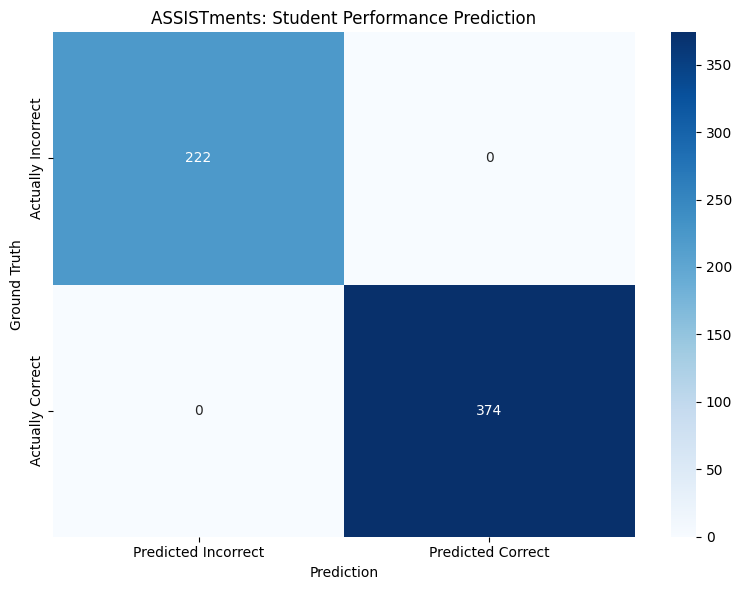

Visualization saved to Google Drive!


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Incorrect', 'Predicted Correct'],
            yticklabels=['Actually Incorrect', 'Actually Correct'])
plt.title('ASSISTments: Student Performance Prediction')
plt.ylabel('Ground Truth')
plt.xlabel('Prediction')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/assistments_confusion_matrix.png', dpi=300)
plt.show()

print("Visualization saved to Google Drive!")